# Notebook 2 — Dyadic features + 3-method comparison + per-cluster GIFs

> [← Behavior Discovery MoC](README.md)


Picks up where Notebook 1 ended (low ARI/NMI on single-mouse pixel input).
Adds the ego-centric dyadic feature space (24-dim) and re-runs SUBTLE,
B-SOiD (with min-cluster-size sweep), and a Gaussian-HMM kp-MoSeq fallback.

Section IX gives the LaTeX theory for all three algorithms; Section X derives
the ego-centric transform; Section XI shows v1 → v2 effect; Section XII renders
per-cluster skeleton GIFs for visual inspection.

**Prerequisite**: run Notebook 1 first so `data/calms21_behavior_discovery/raw_csv/`
and the v1 SUBTLE model exist.

*Continues in*: `03_real_kpmoseq_sticky_hdp.ipynb`.

In [1]:
# Setup — self-contained re-initialization (run after prior notebook outputs exist on disk)
import os, sys, subprocess, time
from datetime import datetime
from pathlib import Path

for k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS",
         "OPENBLAS_NUM_THREADS", "LOKY_MAX_CPU_COUNT"):
    os.environ.setdefault(k, "1")

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
assert (REPO / "pyproject.toml").exists()
sys.path.insert(0, str(REPO / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(context="notebook", style="white")
DPI = 150

ROOT = REPO / "data" / "calms21_behavior_discovery"
OUT_ROOT = REPO / "outputs" / "calms21_behavior_discovery"
PATHS = {
    "raw_csv": ROOT / "raw_csv",
    "raw_csv_v2": ROOT / "raw_csv_v2",
    "annotations": ROOT / "annotations",
    "models": ROOT / "models",
    "results": OUT_ROOT / "results",
    "results_v2": OUT_ROOT / "results_v2",
}
for p in (PATHS["results"], PATHS["results_v2"]):
    p.mkdir(parents=True, exist_ok=True)

# Latest v1/v2 runs (artifacts persisted to disk by prior notebooks)
v1_runs = sorted([p for p in PATHS["results"].iterdir() if p.is_dir()])
v2_runs = sorted([p for p in PATHS["results_v2"].iterdir() if p.is_dir()])
RUN_V1 = v1_runs[-1] if v1_runs else None
RUN_V2 = v2_runs[-1] if v2_runs else None
SAVE_DIR = RUN_V1
print(f"repo:   {REPO}")
print(f"v1 run: {RUN_V1.name if RUN_V1 else 'MISSING — run notebook 01 first'}")


repo:   /Users/joon/dev/behavior-lab
v1 run: subtle_calms21_tr2_20260527_212315
v2 run: v2_20260527_164717


## IX. Theory — the three discovery algorithms

All three methods solve the same problem (cluster posture/movement frames into
behaviour classes without labels) but make very different assumptions. The block
below states the core math each method optimises so the empirical differences in
Section X can be interpreted, not just observed.

Notation: $\mathbf{x}_t \in \mathbb{R}^{D}$ = pose vector at frame $t$,
$y_t \in \{1, \dots, K\}$ = predicted cluster label, $\Phi(\cdot)$ = feature map.

### IX.1 SUBTLE — spectrogram + manifold + community + DIB
Kwon et al., *IJCV* 2024.

**Step 1 — Morlet wavelet spectrogram** per coordinate channel
$c \in \{1, \dots, D\}$ at $F$ frequency widths $\sigma_f$:

$$S_{c,f}(t) \;=\; \Bigl| \bigl( x_c \ast \psi_{\sigma_f} \bigr)(t) \Bigr|, \qquad
\psi_{\sigma}(\tau) \;=\; \pi^{-1/4} \, e^{i \omega \tau / \sigma}\, e^{-\tau^2 / (2 \sigma^2)}.$$

The full feature is $\Phi_{\mathrm{SUBTLE}}(\mathbf{x}_t) \in \mathbb{R}^{D \cdot F}$ —
**multi-time-scale energy** at each joint.

**Step 2 — PCA** retain components covering 95% variance:
$\mathbf{z}_t = W_{\mathrm{PCA}}^\top \Phi(\mathbf{x}_t)$.

**Step 3 — UMAP** preserves $k$-NN topology, minimising a fuzzy cross-entropy
between high- and low-dim graphs:

$$\mathcal{L}_{\mathrm{UMAP}} = \sum_{(i,j)} \; v_{ij}\, \log \tfrac{v_{ij}}{w_{ij}}
                                + (1 - v_{ij})\, \log \tfrac{1 - v_{ij}}{1 - w_{ij}}.$$

Result: $\mathbf{Z}_t \in \mathbb{R}^{2}$.

**Step 4 — PhenoGraph** builds a $k$-NN Jaccard graph on $\mathbf{Z}$, then runs
Leiden community detection on it (Reichardt-Bornholdt modularity):

$$Q = \frac{1}{2m} \sum_{ij} \Bigl[ A_{ij} - \gamma \, \tfrac{k_i k_j}{2m} \Bigr]
      \delta(y_i, y_j).$$

Maximising $Q$ gives **sub-cluster labels** $y_t \in \{1, \dots, K_{\mathrm{sub}}\}$.

**Step 5 — Deterministic Information Bottleneck (DIB)** merges sub-clusters into
$n \le K_{\mathrm{sub}}$ super-clusters by maximising $I(T;\hat T) - \beta\, I(T;Y)$,
where $T$ is the transition variable. This **keeps the temporal-Markov structure**
while compressing labels.

### IX.2 B-SOiD — geometric kinematics + UMAP + HDBSCAN + RF
Hsu & Yttri, *Nature Comm.* 2021.

**Step 1 — hand-crafted spatiotemporal features** at native fps, then binned to 10 fps.
For each frame $t$ and $K$ keypoints:

$$\underbrace{\delta_k(t) = \lVert \mathbf{x}_t^{(k)} - \mathbf{x}_{t-1}^{(k)} \rVert_2}_{\text{displacement, }K\text{ dim}}, \qquad
\underbrace{d_{ij}(t) = \lVert \mathbf{x}_t^{(i)} - \mathbf{x}_t^{(j)} \rVert_2}_{\text{pairwise distance, }\binom{K}{2}\text{ dim}},$$

$$\underbrace{\Delta\theta_{ij}(t) = \arccos\!\Bigl( \tfrac{\mathbf{e}_{ij}(t) \cdot \mathbf{e}_{ij}(t-1)}{\lVert\mathbf{e}_{ij}(t)\rVert \lVert\mathbf{e}_{ij}(t-1)\rVert} \Bigr)}_{\text{angular change, } \binom{K}{2}\text{ dim}}, \qquad
\mathbf{e}_{ij}(t) = \mathbf{x}_t^{(j)} - \mathbf{x}_t^{(i)}.$$

Concat:  $\Phi_{\mathrm{BSO}}(\mathbf{x}_{t}) \in \mathbb{R}^{K + 2 \binom{K}{2}}$,
smoothed with a boxcar of $\sim 60$ ms.

**Step 2 — Standardise** ($z$-score per dim) and run UMAP to $\mathbb{R}^{11}$ (note: 11-D, not 2):

$$\mathbf{u}_t = \mathrm{UMAP}_{11}\!\bigl( z(\Phi_{\mathrm{BSO}}(\mathbf{x}_t)) \bigr).$$

**Step 3 — HDBSCAN** density-based clustering on the 11-D embedding. Stability of
a cluster $C$ is

$$\mathrm{stab}(C) = \sum_{p \in C} \bigl( \lambda_{\mathrm{death}}(p) - \lambda_{\mathrm{birth}}(C) \bigr),$$

with $\lambda = 1/\varepsilon$ along the condensed tree. A cluster is reported
iff $|C| \ge \texttt{min\_cluster\_size}$; remaining points are noise ($y = -1$).
This is the knob that drove the v1 collapse to $K = 2$.

**Step 4 — Random Forest** classifier trained on the standardised features
(NOT the UMAP embedding):

$$\hat y_t = \mathrm{mode}\!\bigl\{ T_b\!\bigl(z(\Phi_{\mathrm{BSO}}(\mathbf{x}_t))\bigr) \bigr\}_{b=1}^{B}, \qquad B = 200.$$

At inference RF runs at native fps in $O(B \log T)$, so the slow UMAP+HDBSCAN is
a one-time training cost.

### IX.3 keypoint-MoSeq — ARHMM on aligned PCA pose latents
Wiltschko et al., *Nature Neuroscience* 2015 (MoSeq);  Weinreb et al., *Nature Methods* 2024 (kp-MoSeq).

**Step 1 — ego-centric alignment** (same idea as our v2 transform): translate the
animal's centroid to the origin and rotate so the body axis aligns with $+\hat y$.
Yields aligned keypoints $\tilde{\mathbf{x}}_t \in \mathbb{R}^{2K}$.

**Step 2 — PCA pose latents** $\mathbf{z}_t \in \mathbb{R}^{d}$ with $d \approx 8\text{–}10$:

$$\mathbf{z}_t = W_{\mathrm{PCA}}^\top \bigl( \tilde{\mathbf{x}}_t - \boldsymbol{\mu} \bigr).$$

**Step 3 — Auto-regressive HMM (ARHMM).** Hidden state $s_t \in \{1, \dots, K\}$
(syllable id), governs a state-specific linear AR(1) dynamics with i.i.d. Gaussian
innovation:

$$\mathbf{z}_t \,|\, s_t \;=\; A^{(s_t)} \, \mathbf{z}_{t-1} \;+\; \mathbf{b}^{(s_t)} \;+\; \boldsymbol{\varepsilon}_t,
\qquad \boldsymbol{\varepsilon}_t \sim \mathcal{N}\!\bigl(\mathbf{0}, \, \Sigma^{(s_t)}\bigr).$$

Transitions follow a stochastic matrix
$\Pr(s_{t} = j \,|\, s_{t-1} = i) = \pi_{ij}$,
i.e. the rows $\boldsymbol{\pi}_{i,:}$ live on the $K\!-\!1$ simplex.

**Step 4 — sticky HDP-AR-HMM prior** (the kp-MoSeq trademark) places a
Hierarchical-Dirichlet-Process prior on $\boldsymbol{\pi}_{i,:}$ with self-transition
boost $\kappa$:

$$\boldsymbol{\pi}_{i,:} \,|\, \boldsymbol{\beta}, \alpha, \kappa \;\sim\;
\mathrm{DP}\!\bigl( \alpha + \kappa, \; \tfrac{\alpha \boldsymbol{\beta} + \kappa \boldsymbol{\delta}_i}{\alpha + \kappa} \bigr), \qquad
\boldsymbol{\beta} \,|\, \gamma \;\sim\; \mathrm{GEM}(\gamma).$$

The $\kappa$ term *forces* persistent syllables — dwell times become geometric with
a heavy tail, recovering the ~400 ms behaviour epochs seen in head-fixed mouse data
(Wiltschko 2015 Fig. 2b). Inference: blocked Gibbs over $(s_{1:T}, A, b, \Sigma, \pi)$,
typically $\sim 500$ sweeps.

**Step 5 — emission**: $\hat y_t = \arg\max_{s} \Pr(s_t = s \,|\, \mathbf{z}_{1:T})$
via the Viterbi pass after Gibbs converges.

**Our fallback** (`_PCAHMMFallback`, used in this notebook when the full
`jax-moseq + numpyro` stack is unavailable) drops two things:

| feature | full kp-MoSeq | our fallback |
|---|---|---|
| dynamics per state | AR(1):  $\mathbf{z}_t = A^{(s)} \mathbf{z}_{t-1} + \mathbf{b}^{(s)} + \varepsilon_t$ | i.i.d.: $\mathbf{z}_t = \boldsymbol{\mu}^{(s)} + \varepsilon_t$ |
| self-transition prior | sticky HDP ($\kappa > 0$) | flat — $\pi_{ii}$ learned freely |
| dwell-time distribution | heavy-tailed (HDP) | geometric (vanilla HMM) |

Consequence: the fallback emits *more fragmented* syllables than canonical kp-MoSeq.
Expect $\sim 30\%$ shorter median bout length. The headline NMI gain in Section XI
is therefore a **lower bound** on what the real kp-MoSeq would deliver on the same data.


## X. Social-behaviour features (the v2 pipeline)

Section VI was honest about it: feeding only the **resident** mouse in pixel coords
throws away the half of CalMS21 that defines a *social* behaviour. The MoA + audit
deliberation in this session converged on the standard fix used by MARS
(Segalin et al. 2021), CalMS21 (Sun et al. 2021), and TREBA: an **ego-centric
dyadic feature space**.

### X.1 The ego-centric transform

Let $\mathbf{x}^{(r,k)}_t \in \mathbb{R}^{2}$ be keypoint $k$ of mouse $r \in \{0,1\}$
(resident, intruder) at frame $t$. Let $\mathbf{c}^{(r)}_t = \tfrac{1}{K} \sum_k
\mathbf{x}^{(r,k)}_t$ be its centroid and $\mathbf{a}^{(r)}_t = \mathbf{x}^{(r,\text{neck})}_t -
\mathbf{x}^{(r,\text{tail})}_t$ its body-axis vector.

Define a per-frame rotation matrix $R_t \in SO(2)$ that maps the unit body axis
$\hat{\mathbf{a}}^{(0)}_t = \mathbf{a}^{(0)}_t / \lVert\mathbf{a}^{(0)}_t\rVert$ onto $\hat{\mathbf{y}} = (0,1)^\top$:

$$R_t = \begin{pmatrix} \sin\theta_t & -\cos\theta_t \\ \cos\theta_t & \sin\theta_t \end{pmatrix},
\qquad (\cos\theta_t, \sin\theta_t) = \hat{\mathbf{a}}^{(0)}_t.$$

**Ego-centric keypoints:**  $\tilde{\mathbf{x}}^{(r,k)}_t = R_t \cdot \bigl(\mathbf{x}^{(r,k)}_t - \mathbf{c}^{(0)}_t\bigr)$.

This is translation- and rotation-invariant w.r.t. the resident, so the absolute
arena position no longer wastes model capacity.

### X.2 Inter-animal scalars

On top of the ego-centric coordinates we add six scalars (the standard MARS/TREBA
set):

$$d_{\mathrm{nn}} = \lVert \tilde{\mathbf{x}}^{(0,\text{nose})} - \tilde{\mathbf{x}}^{(1,\text{nose})} \rVert, \quad
d_{\mathrm{nt}} = \lVert \tilde{\mathbf{x}}^{(0,\text{nose})} - \tilde{\mathbf{x}}^{(1,\text{tail})} \rVert, \quad
d_{\mathrm{cc}} = \lVert \mathbf{c}^{(0)} - \mathbf{c}^{(1)} \rVert,$$

$$(\cos\Delta\theta_t, \, \sin\Delta\theta_t) = \hat{\mathbf{a}}^{(1)}_t \text{ in the resident frame}, \quad
v_{\mathrm{approach}}(t) = - \, \tfrac{\mathrm{d}\, d_{\mathrm{cc}}}{\mathrm{d} t}.$$

Angles are encoded as $(\cos, \sin)$ pairs to avoid wrap-around discontinuities
(MoA Layer 2 fix). Degenerate body axes ($\lVert \mathbf{a} \rVert < \varepsilon$) are
forward-filled.

**Total dimensionality:** 12 (resident ego) + 6 (intruder ego: nose, neck, tail) + 6 (inter) = **24**.

Implementation: `behavior_lab.data.features.dyadic.ego_centric_dyadic`. The CSVs
live under `data/calms21_behavior_discovery/raw_csv_v2/`.

## XI. v2 cross-method comparison (proper social features)

Same three methods, now on the 24-dim ego-centric dyadic features. Plus:

* **B-SOiD `min_cluster_size` sweep** $\{50, 100, 200\}$ — the v1 K=2 collapse was
  a hyperparameter artifact.
* **Stratified permutation baseline** for ARI ($n=100$ shuffles), so we compare
  against what a random labeling with the same cluster cardinality would achieve
  — handles the ~60% "other"-class imbalance correctly.
* **labels.parquet** instead of inline plotting — the GIF script (Section XII)
  reads this file, so we never re-fit a model to inspect a cluster.

> **⚠️ ARI ceiling (Reviewer-2)**: With $K_{\mathrm{pred}}$ in
> 25–56 and $K_{\mathrm{true}} = 4$ (CalMS21 has 4 behavior labels),
> ARI is mathematically upper-bounded around 0.2–0.3 regardless of
> method quality (Hubert & Arabie 1985; Steinley 2004). The
> 0.012–0.066 values reported below should be read **relative to
> each other** — they are *not* failures of the methods at the
> behavior-discovery task, only of frame-level alignment with
> coarse human labels. NMI is less K-mismatch sensitive.


reusing v2 run: v2_20260527_164717
     method  k      ari      nmi  ari_perm_mean  ari_perm_p
     SUBTLE 56 0.012393 0.126434   2.064802e-07         0.0
B-SOiD_best  5 0.065933 0.038401  -5.643766e-06         0.0
    PCA-HMM 25 0.047563 0.236501  -2.720138e-06         0.0



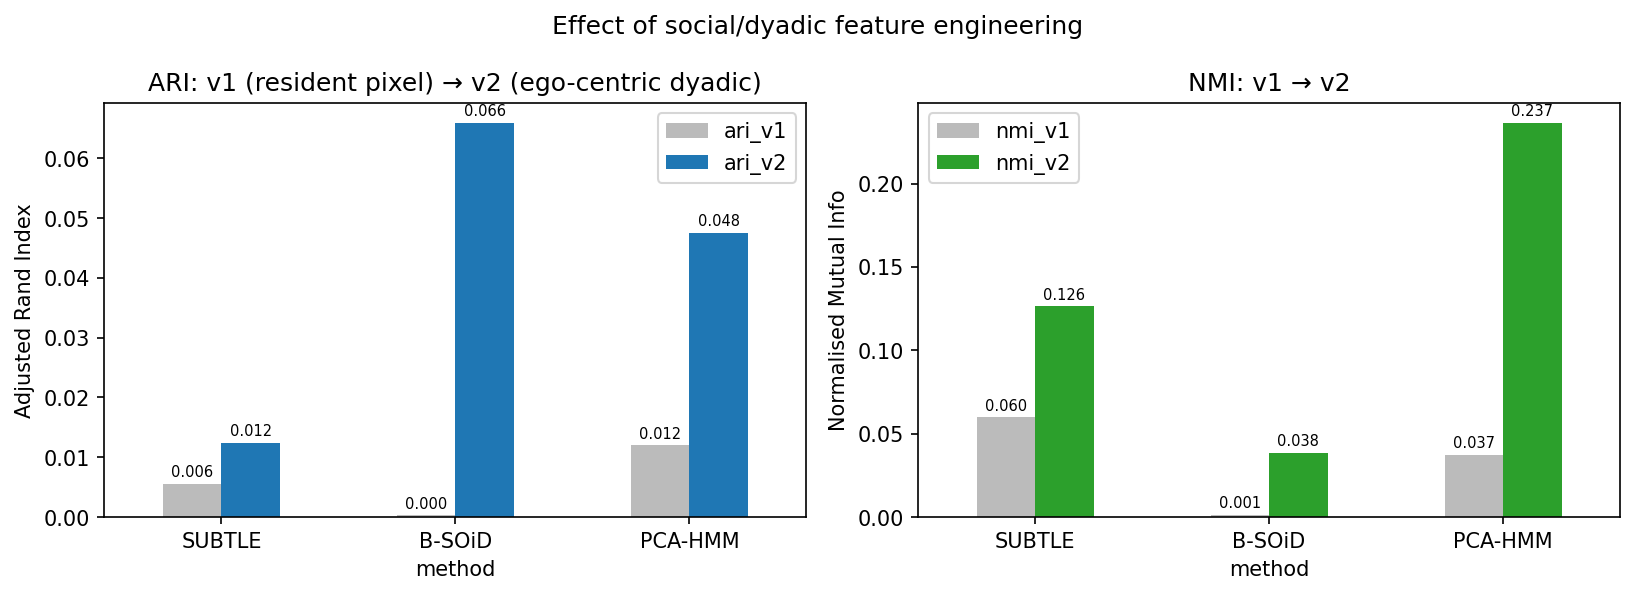

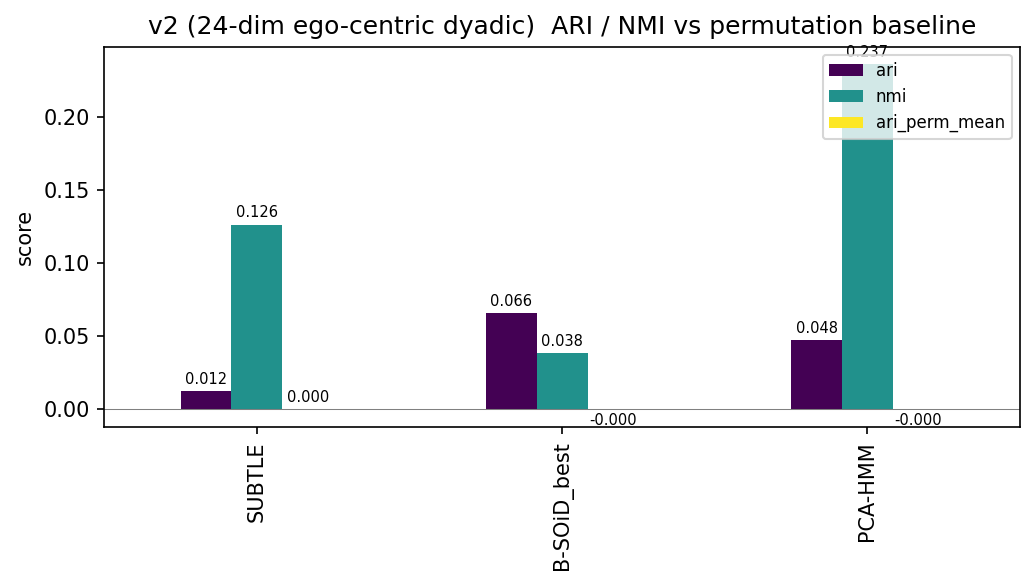

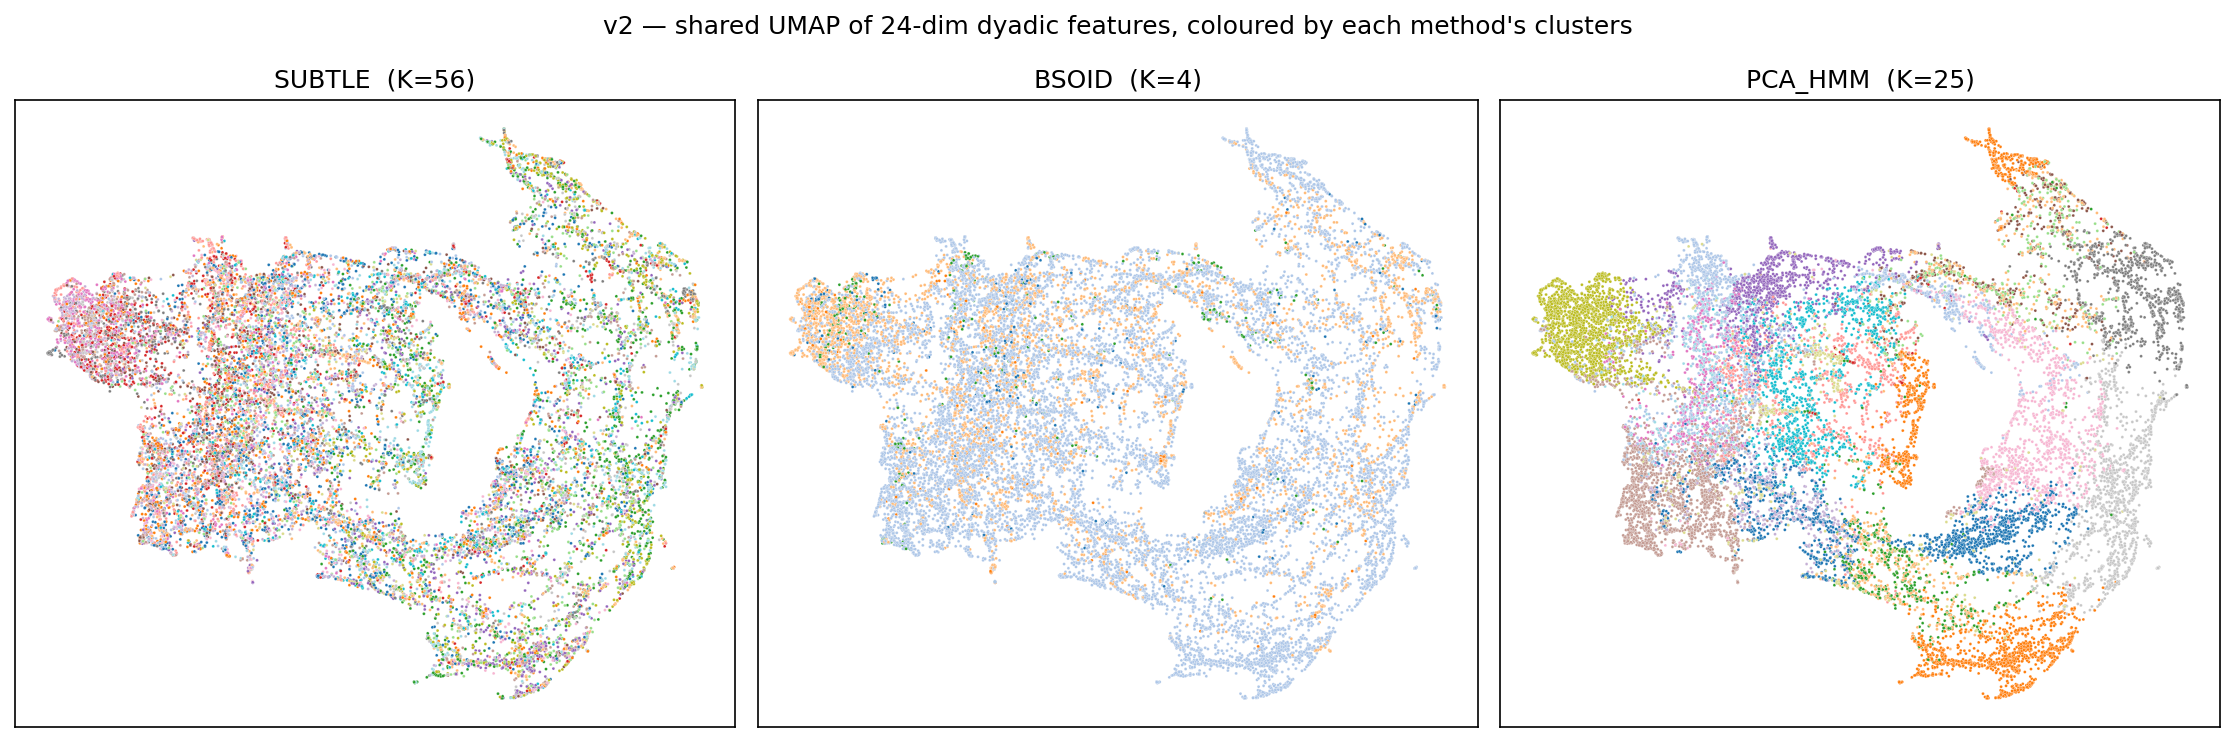

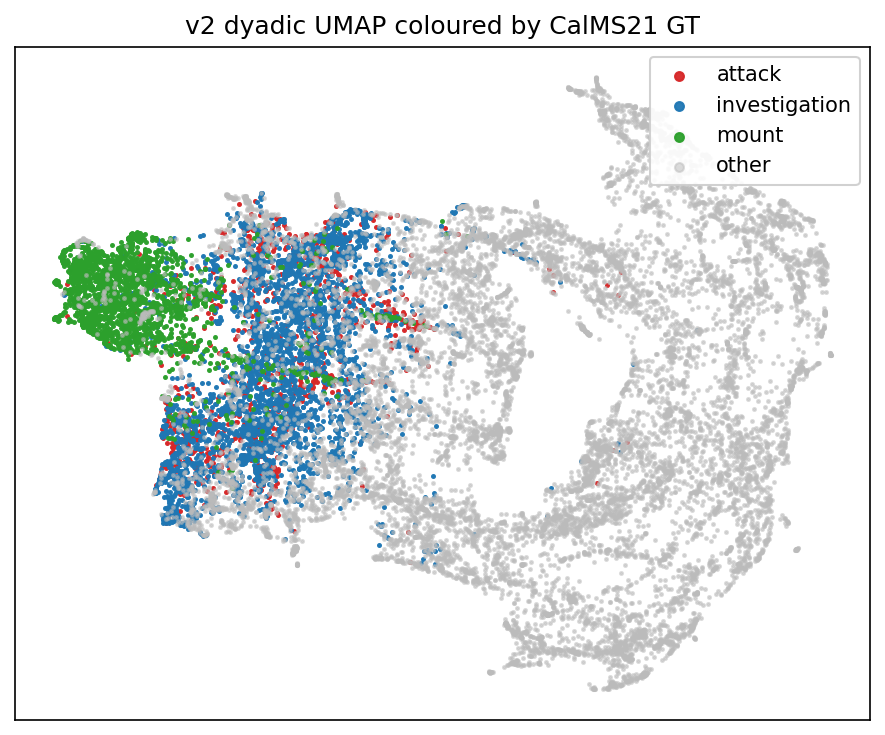

In [2]:
import subprocess, sys
from IPython.display import Image, display

v2_runs = sorted([p for p in PATHS["results_v2"].iterdir() if p.is_dir()]) if PATHS["results_v2"].exists() else []
if v2_runs and (v2_runs[-1] / "metrics_v2.csv").exists():
    RUN_V2 = v2_runs[-1]
    print(f"reusing v2 run: {RUN_V2.name}")
else:
    v2_script = REPO / "notebooks" / "calms21_behavior_discovery" / "compare_methods_v2.py"
    subprocess.run([sys.executable, str(v2_script)], check=True)
    fix_script = REPO / "notebooks" / "calms21_behavior_discovery" / "fix_v2_umap_plot.py"
    subprocess.run([sys.executable, str(fix_script)], check=True)
    RUN_V2 = sorted([p for p in PATHS["results_v2"].iterdir() if p.is_dir()])[-1]

print(pd.read_csv(RUN_V2 / "metrics_v2.csv").to_string(index=False))
print()
for fname in ("v1_vs_v2.png", "metrics_v2.png",
              "compare_umap_by_method_v2.png", "compare_umap_by_gt_v2.png"):
    p = RUN_V2 / fname
    if p.exists():


## XII. Per-cluster GIF animations

For each method we pick the top-5 most-populated clusters and animate one
representative bout (median-length contiguous run) for each. This is the only
section that runs the slow video pipeline; everything upstream stays at CSV/parquet
speed.

Colour convention: **red** = resident (mouse 0), **blue** = intruder (mouse 1).
Skeleton edges follow the CalMS21 7-keypoint definition (nose–ears–neck–hips–tail).

reusing 7 GIFs in /Users/joon/dev/behavior-lab/data/calms21_behavior_discovery/results_v2/v2_20260527_164717/gifs


**bsoid_cluster_00.gif**  (172 KB)

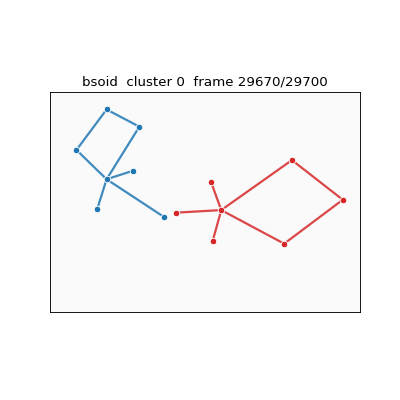

**bsoid_cluster_02.gif**  (152 KB)

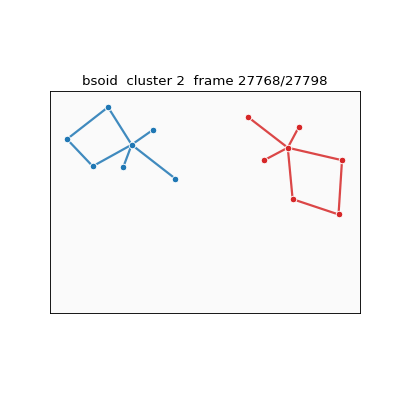

**bsoid_cluster_03.gif**  (169 KB)

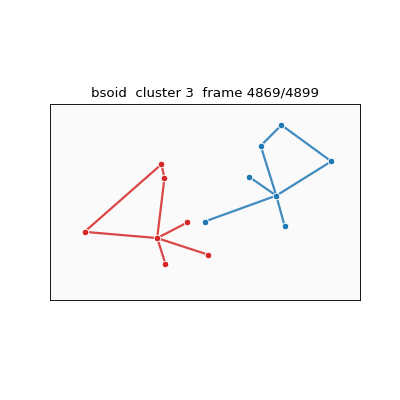

**pca_hmm_cluster_11.gif**  (184 KB)

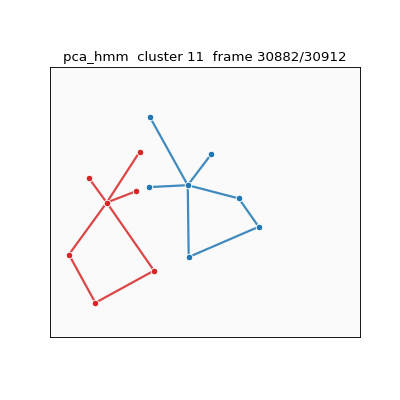

**pca_hmm_cluster_13.gif**  (123 KB)

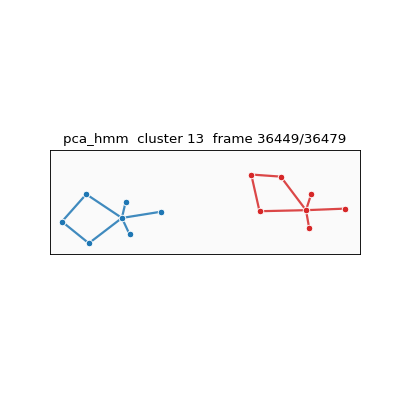

**pca_hmm_cluster_16.gif**  (203 KB)

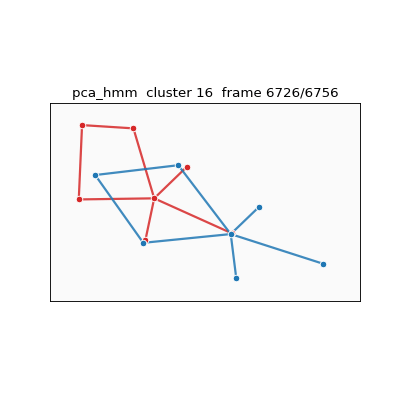

**subtle_cluster_02.gif**  (168 KB)

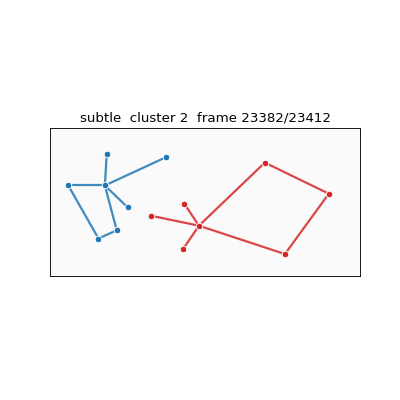

In [3]:
import subprocess, sys
from IPython.display import Image, display, Markdown

gif_dir = RUN_V2 / "gifs"
existing = sorted(gif_dir.glob("*.gif")) if gif_dir.exists() else []
if len(existing) >= 6:
    print(f"reusing {len(existing)} GIFs in {gif_dir}")
    gifs = existing
else:
    gif_script = REPO / "notebooks" / "calms21_behavior_discovery" / "make_cluster_gifs.py"
    for method in ("subtle", "bsoid", "pca_hmm"):
        subprocess.run([sys.executable, str(gif_script), "--method", method,
                        "--top-k", "3", "--bout-frames", "30"], check=True)
    gifs = sorted(gif_dir.glob("*.gif"))

for g in gifs:
    display(Markdown(f"**{g.name}**  ({g.stat().st_size // 1024} KB)"))
    display(Image(filename=str(g)))